In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pathlib

import catboost as cb
import dotenv
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from loguru import logger
from scipy.special import ndtr
from sklearn import metrics, pipeline

import highres_ta as ta

BASE = pathlib.Path(dotenv.find_dotenv("pyproject.toml")).parent

# Data loading and preprocessing

In [3]:
COORD_COLUMNS = [
    "expocode",
    "time",
    "lat",
    "lon",
    "depth",
]
TARGET_NAME = "talk"
FEATURE_NAMES = [
    "salinity",
    "temperature",
    "ssh_adt",
    "nitrate",
    "phosphate",
    "silicate",
    "bottomdepth",
]
QC_COLS = ["talkqc", "talkf"]
REQUIRED_COLUMNS = list(set(COORD_COLUMNS + FEATURE_NAMES + [TARGET_NAME] + QC_COLS))
NONAN_SUBSET = [TARGET_NAME, "salinity", "temperature", "nitrate", "ssh_adt"]
LINEAR_FEATURES = ["salinity", "temperature"]
FEATURE_NAMES += [
    "ncoord_x",
    "ncoord_y",
    "ncoord_z",
]

In [4]:
data = (
    ta
    .load_data()[REQUIRED_COLUMNS]
    .set_index(COORD_COLUMNS, drop=False)
    .pipe(ta.drop_extreme_salinities, min=20, max=40)
    .pipe(
        ta.add_talk_adjustment,
        fname=str(BASE / "data" / "glodapv2_adjustments_last_updated_on_2026_07_09.csv"),
    )
    .pipe(ta.drop_bad_quality_talk)
    .dropna(subset=NONAN_SUBSET)
    .drop_duplicates(subset=COORD_COLUMNS, keep="first")
    .select_dtypes(include=[np.number])
    .pipe(ta.add_cyclical_dayofyear)
    .pipe(ta.add_spherical_coords)
    .loc[:, FEATURE_NAMES + [TARGET_NAME]]
)

data.shape


2026-08-21 11:05:40.698 | DEBUG    | highres_ta.dataio:load_data:18 - Loading 40 .pq files from ../data/training
2026-08-21 11:05:41.310 | DEBUG    | highres_ta.target_filtering:drop_bad_quality_talk:49 - TA values with large adjustments (<= 6.0 mol/kg): 2365
2026-08-21 11:05:41.311 | DEBUG    | highres_ta.target_filtering:drop_bad_quality_talk:52 - TA values without good flags (!= 2): 3046
2026-08-21 11:05:41.312 | INFO     | highres_ta.target_filtering:drop_bad_quality_talk:53 - Number of rows filtered due to large adjustments and bad flags: 5319 of 41534 (13%)


(27210, 11)

## Train test split

In [5]:
train_idx, test_idx = ta.make_train_test_folds(data, n_splits=6)[5]
test = data.iloc[test_idx]
train = data.iloc[train_idx]
train_folds = ta.make_train_test_folds(train, shuffle=False)

2026-08-21 11:05:41.471 | DEBUG    | highres_ta.train_test_split:make_salinity_bins:48 - Using the following bin edges for salinity: [20.1909  32.8038  34.05706 34.819   35.535   39.231  ]
2026-08-21 11:05:41.479 | DEBUG    | highres_ta.train_test_split:stratified_group_folds:96 - Making train-test splits stratified by salinity_bin and grouped by expocode
2026-08-21 11:05:41.693 | DEBUG    | highres_ta.train_test_split:make_salinity_bins:48 - Using the following bin edges for salinity: [20.1909 32.8036 34.0576 34.819  35.535  39.231 ]
2026-08-21 11:05:41.698 | DEBUG    | highres_ta.train_test_split:stratified_group_folds:96 - Making train-test splits stratified by salinity_bin and grouped by expocode


# CatBoost tuning

## Multi-objective hyperparameter tuning with nested cross-validation

Optuna tunes CatBoost on the outer training split only. Each inner fold fits its own linear baseline before training CatBoost on residuals, preventing validation-fold leakage. The two objectives are median validation RMSE and median validation Gaussian CRPS. RMSE measures point-prediction accuracy; CRPS jointly rewards calibrated and sharp predictive uncertainty.

In [6]:
RANDOM_SEED = 42
N_TRIALS = 400
N_JOBS = 36
NUM_THREADS = 2
EARLY_STOPPING_ROUNDS = 50
ALWAYS_IGNORED_FEATURES = sorted(set(COORD_COLUMNS).intersection(FEATURE_NAMES))

fixed_catboost_params = {
    "loss_function": "RMSEWithUncertainty",
    "iterations": 2000,
    "random_seed": RANDOM_SEED,
    "ignored_features": ALWAYS_IGNORED_FEATURES,
    "allow_writing_files": False,
    "thread_count": NUM_THREADS,
    "verbose": False,
    "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
}

fixed_catboost_params

{'loss_function': 'RMSEWithUncertainty',
 'iterations': 2000,
 'random_seed': 42,
 'ignored_features': [],
 'allow_writing_files': False,
 'thread_count': 2,
 'verbose': False,
 'early_stopping_rounds': 50}

### Gaussian CRPS

For `RMSEWithUncertainty`, `CatBoostResidualRegressor.predict` returns two columns: predictive mean and predictive variance. The function below evaluates the closed-form CRPS of that Gaussian predictive distribution for every observation.

In [7]:
def gaussian_crps(y_true, prediction, min_variance=1e-12):
    """Return observation-wise CRPS for Gaussian mean/variance predictions."""
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    prediction = np.asarray(prediction, dtype=float)

    if prediction.ndim != 2 or prediction.shape[1] != 2:
        raise ValueError("prediction must have columns [mean, variance]")
    if prediction.shape[0] != y_true.size:
        raise ValueError("y_true and prediction must contain the same number of rows")

    mean = prediction[:, 0]
    sigma = np.sqrt(np.maximum(prediction[:, 1], min_variance))
    z = (y_true - mean) / sigma
    pdf = np.exp(-0.5 * z**2) / np.sqrt(2.0 * np.pi)
    return sigma * (z * (2.0 * ndtr(z) - 1.0) + 2.0 * pdf - 1.0 / np.sqrt(np.pi))

In [8]:
def objective(trial: optuna.Trial) -> tuple[float, float]:
    trial_params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 1.00, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 100.0, log=True),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 100),
        "depth": trial.suggest_int("depth", 4, 12),
        "rsm": trial.suggest_float("rsm", 0.0, 1.0),
        "random_strength": trial.suggest_float("random_strength", 1, 10.0),
    }

    fold_rmse = []
    fold_crps = []
    fold_r2score = []
    fold_best_iterations = []
    boost_kwargs = fixed_catboost_params | trial_params

    for fold_train_idx, fold_valid_idx in train_folds:
        fold_model = ta.CatBoostResidualRegressor(
            linear_features=LINEAR_FEATURES,
            feature_names=FEATURE_NAMES,
            **boost_kwargs,
        )

        x_train = train.iloc[fold_train_idx].loc[:, FEATURE_NAMES]
        y_train = train.iloc[fold_train_idx].loc[:, TARGET_NAME]
        x_valid = train.iloc[fold_valid_idx].loc[:, FEATURE_NAMES]
        y_valid = train.iloc[fold_valid_idx].loc[:, TARGET_NAME]

        fold_model.fit(x_train, y_train, eval_set=(x_valid, y_valid))
        prediction = fold_model.predict(x_valid)

        fold_rmse.append(float(metrics.root_mean_squared_error(y_valid, prediction[:, 0])))
        fold_crps.append(float(np.mean(gaussian_crps(y_valid, prediction))))
        fold_r2score.append(float(metrics.r2_score(y_valid, prediction[:, 0])))
        fold_best_iterations.append(fold_model.boosting_model_.get_best_iteration() + 1)

    trial.set_user_attr("fold_rmse", fold_rmse)
    trial.set_user_attr("fold_crps", fold_crps)
    trial.set_user_attr("fold_r2score", fold_r2score)
    trial.set_user_attr("fold_best_iterations", fold_best_iterations)
    trial.set_user_attr("refit_iterations", int(np.median(fold_best_iterations)))

    return float(np.median(fold_rmse)), float(np.median(fold_crps))

In [9]:
sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)
study = optuna.create_study(
    directions=["minimize", "minimize"],
    sampler=sampler,
    storage="sqlite:///catboost_rmse_crps_cv.db",
    study_name="catboost_rmse_crps_RMSEWithUncertainty_v02",
    load_if_exists=True,
)
study.set_metric_names(["rmse", "crps"])
study.optimize(objective, n_trials=N_TRIALS, n_jobs=N_JOBS, show_progress_bar=True)

[I 2026-08-21 11:05:42,645] Using an existing study with name 'catboost_rmse_crps_RMSEWithUncertainty_v02' instead of creating a new one.
/tmp/ipykernel_3799853/944085151.py:9: ExperimentalWarning: optuna.study.study.Study.set_metric_names is experimental (supported from v3.2.0). The interface can change in the future.
  study.set_metric_names(["rmse", "crps"])


  0%|          | 0/400 [00:00<?, ?it/s]

[I 2026-08-21 11:05:51,490] Trial 26 finished with values: {'rmse': 29.234387488669363, 'crps': 10.607938070474038} and parameters: {'learning_rate': 0.6242619468994012, 'l2_leaf_reg': 1.3598658545861912, 'min_data_in_leaf': 60, 'depth': 6, 'rsm': 0.23173543725410117, 'random_strength': 7.642620045284187}.
[I 2026-08-21 11:05:52,221] Trial 21 finished with values: {'rmse': 31.13760797486454, 'crps': 12.498236316186357} and parameters: {'learning_rate': 0.8320413578791029, 'l2_leaf_reg': 3.3770845014977455, 'min_data_in_leaf': 33, 'depth': 7, 'rsm': 0.062162183755925304, 'random_strength': 8.184406152780236}.
[I 2026-08-21 11:05:52,371] Trial 11 finished with values: {'rmse': 32.76188501901986, 'crps': 13.9300274834393} and parameters: {'learning_rate': 0.3275938640011183, 'l2_leaf_reg': 85.75178205220725, 'min_data_in_leaf': 30, 'depth': 9, 'rsm': 0.007097892298492781, 'random_strength': 9.251500032647753}.
[I 2026-08-21 11:05:52,454] Trial 20 finished with values: {'rmse': 30.40951956

## Pareto front and balanced trial selection

A multi-objective study has no single best trial. For the final refit, the next cell normalizes RMSE and CRPS over the Pareto front and chooses the trial closest to the ideal point `(0, 0)`. This gives both objectives equal weight after accounting for their different scales.

In [10]:
from optuna import visualization

cv_results = study.trials_dataframe(
    attrs=("number", "values", "params", "user_attrs", "state")
)
pareto_trials = study.best_trials
pareto_values = np.asarray([trial.values for trial in pareto_trials], dtype=float)
objective_range = np.ptp(pareto_values, axis=0)
objective_range = np.where(objective_range > 0.0, objective_range, 1.0)
normalized_values = (pareto_values - pareto_values.min(axis=0)) / objective_range
selected_trial = pareto_trials[np.linalg.norm(normalized_values, axis=1).argmin()]

print(f"Pareto-optimal trials: {len(pareto_trials)}")
print(f"Selected trial: {selected_trial.number}")
print(f"Selected median CV RMSE: {selected_trial.values[0]:.3f}")
print(f"Selected median CV CRPS: {selected_trial.values[1]:.3f}")
print(f"Refit iterations: {selected_trial.user_attrs['refit_iterations']}")

display(
    cv_results.loc[cv_results["number"].isin([trial.number for trial in pareto_trials])]
    .sort_values(["values_rmse", "values_crps"])
    .reset_index(drop=True)
)
visualization.plot_pareto_front(study, target_names=["CV RMSE", "CV CRPS"])

Pareto-optimal trials: 1
Selected trial: 240
Selected median CV RMSE: 20.893
Selected median CV CRPS: 8.006
Refit iterations: 44


,number,values_crps,values_rmse,params_depth,params_l2_leaf_reg,params_learning_rate,params_min_data_in_leaf,params_random_strength,params_rsm,user_attrs_fold_best_iterations,user_attrs_fold_crps,user_attrs_fold_r2score,user_attrs_fold_rmse,user_attrs_refit_iterations,state
0,240,8.006263,20.893425,8,15.081389,0.170233,80,2.543389,0.340891,"[60, 44, 86, 44, 23]","[6.948889169813475, 9.54871922922181, 8.006263...","[0.9667450231556864, 0.9190183679822117, 0.954...","[17.971907823437288, 29.373796394136743, 20.89...",44.0,COMPLETE


# Refit and held-out evaluation

The balanced Pareto-optimal hyperparameters are refit on all outer-training observations. The held-out test split is used once for final point and uncertainty metrics; it was not used by Optuna or early stopping.

{'loss_function': 'RMSEWithUncertainty', 'iterations': 44, 'random_seed': 42, 'ignored_features': [], 'allow_writing_files': False, 'thread_count': 2, 'verbose': False, 'early_stopping_rounds': 50, 'learning_rate': 0.17023302306224847, 'l2_leaf_reg': 15.081388526262907, 'min_data_in_leaf': 80, 'depth': 8, 'rsm': 0.34089100856348575, 'random_strength': 2.5433885279252713}


<Axes: title={'center': 'Feature Importance'}>

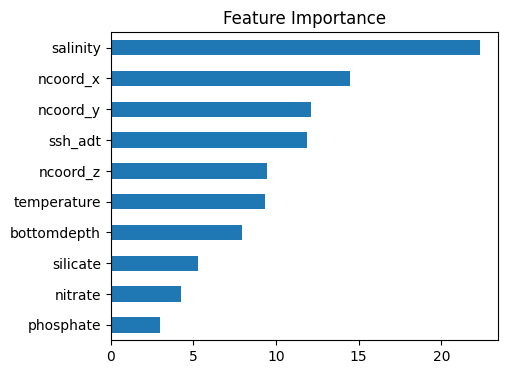

In [11]:
best_params = {
    **(fixed_catboost_params | selected_trial.params),
    "iterations": selected_trial.user_attrs["refit_iterations"],
}
print(best_params)
boosted_trees_model = ta.CatBoostResidualRegressor(
    LINEAR_FEATURES,
    FEATURE_NAMES,
    polynomial_degree=1,
    **best_params,
)
boosted_trees_model.fit(train[FEATURE_NAMES], train[TARGET_NAME])

feature_importance = pd.Series(
    boosted_trees_model.boosting_model_.feature_importances_,
    index=boosted_trees_model.boosting_model_.feature_names_,
).sort_values()

feature_importance.plot.barh(figsize=(5, 4), title="Feature Importance")


In [25]:
subset = test
mask = (subset.bottomdepth > 300) #& (subset.index.to_frame().lat.abs() < 60)
subset = subset[mask]

test_prediction = boosted_trees_model.predict(subset[FEATURE_NAMES])
test_mean = test_prediction[:, 0]
resid = (test_mean - subset[TARGET_NAME]).values
test_std = np.sqrt(np.maximum(test_prediction[:, 1], 1e-12))
test_crps = gaussian_crps(subset[TARGET_NAME], test_prediction)
test_residual = np.asarray(subset[TARGET_NAME]) - test_mean

test_metrics = pd.Series(
    {
        "count": mask.sum(),
        "rmse": metrics.root_mean_squared_error(subset[TARGET_NAME], test_mean),
        "crps": np.mean(test_crps),
        "mae": metrics.mean_absolute_error(subset[TARGET_NAME], test_mean),
        "bias (mean)": (test_mean - subset[TARGET_NAME]).mean(),
        "bias (median)": (test_mean - subset[TARGET_NAME]).median(),
        "r2": metrics.r2_score(subset[TARGET_NAME], test_mean),
        "mean_predicted_std": np.mean(test_std),
        "empirical_95pct_coverage": np.mean(np.abs(test_residual) <= 1.96 * test_std),
    },
    name="held_out_test",
)
test_metrics.round(3)

count                       3864.000
rmse                          14.835
crps                           6.283
mae                            8.845
bias (mean)                    0.154
bias (median)                  0.495
r2                             0.975
mean_predicted_std             9.574
empirical_95pct_coverage       0.905
Name: held_out_test, dtype: float64

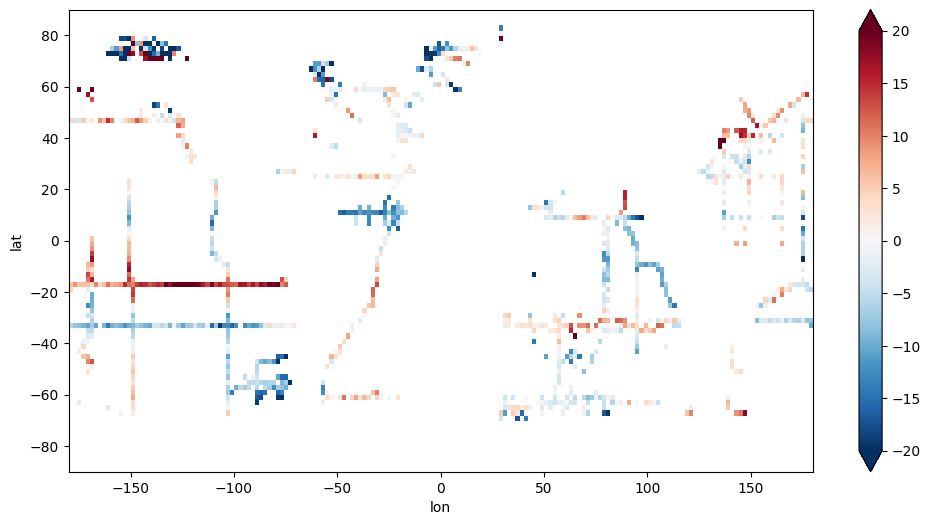

In [26]:
coords = subset.index.to_frame()
coords["lat025"] = (coords["lat"] * 4) // 4 + 0.125
coords["lon025"] = (coords["lon"] * 4) // 4 + 0.125
grid_index = pd.MultiIndex.from_arrays(
    [coords["lat025"].to_numpy(), coords["lon025"].to_numpy()],
    names=["lat", "lon"],
)

(
    pd
    .Series(test_residual, index=grid_index)
    .groupby(["lat", "lon"])
    .mean()
    .to_xarray()
    .reindex(
        lon=np.arange(-180 + 0.125, 180, 0.25),
        lat=np.arange(-90 + 0.125, 90, 0.25),
    )
    .coarsen(lat=8, lon=8)
    .mean()
    .plot.imshow(
        center=0,
        vmin=-20,
        vmax=20,
        cmap="RdBu_r",
        aspect=2,
        size=6,
    )
)
